In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


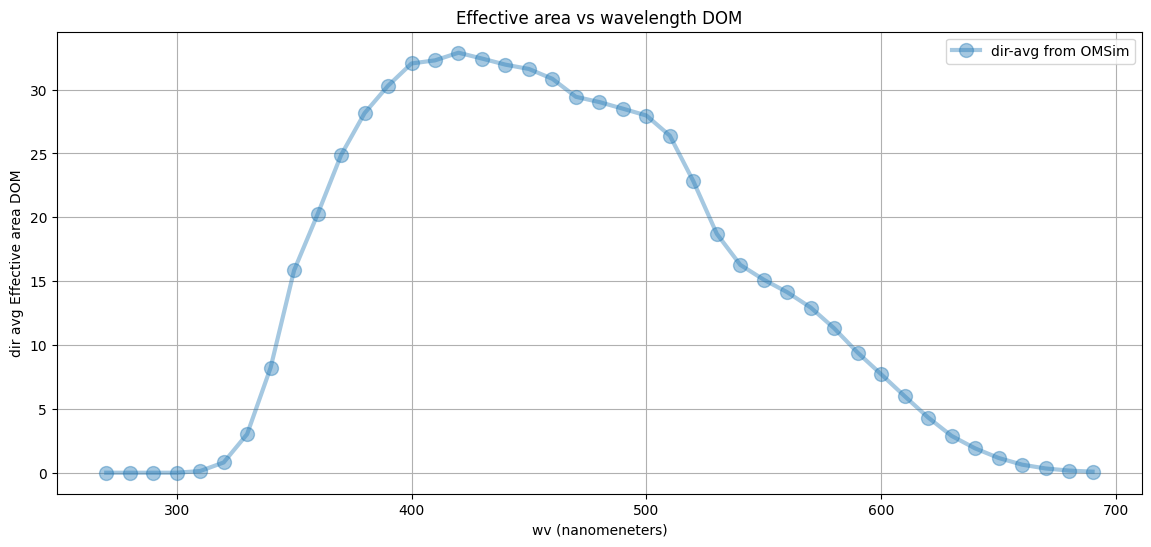

In [4]:
dir = 'Output_WithHarness/'


plt.figure(figsize=(14,6))
wvs =np.arange(270, 700, 10)
dir_avg_eff_areas =[]
for wv in wvs:
    om_file = 'DOM_' + str(wv) + ".txt"
    df = pd.read_csv(dir + om_file, delimiter='\t', skiprows=0)

    dir_avg_eff_area = np.mean(df['PMT0 '])
    dir_avg_eff_areas.append(dir_avg_eff_area)

plt.plot(wvs,dir_avg_eff_areas,'o-', lw = 3, markersize = 10, alpha = 0.4, label='dir-avg from OMSim')

plt.legend()
plt.xlabel('wv (nanomeneters)')
plt.ylabel('dir avg Effective area DOM')
plt.title('Effective area vs wavelength DOM')
  #  plt.legend()
plt.grid()


Grouped DataFrame shape: (2709, 5)
Columns: ['theta', 'wavelength', 'mean_effective_area', 'mean_PMT0', 'n_phi_values']


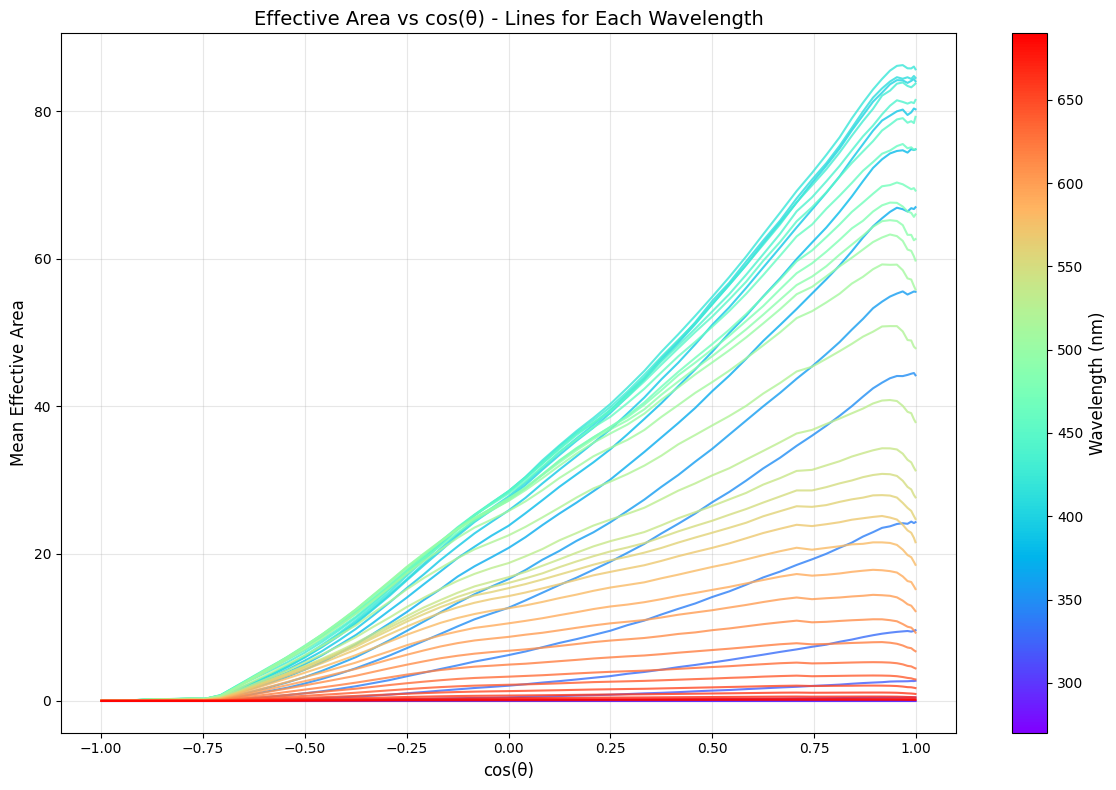

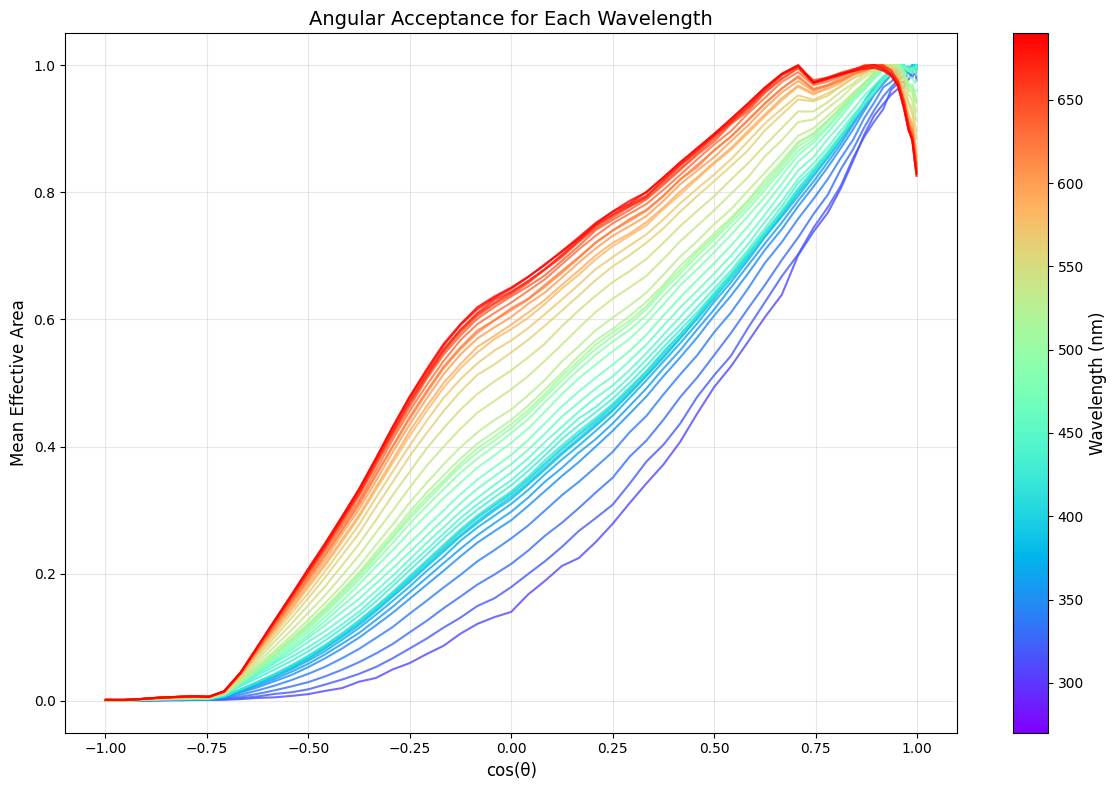

In [5]:

wvs = np.arange(270, 700, 10)

all_dfs = []

for wv in wvs:
    om_file = 'DOM_' + str(wv) + ".txt"
    df = pd.read_csv(dir + om_file, delimiter='\t', skiprows=0)
    
    df['wavelength'] = wv
    
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)


grouped_df = combined_df.groupby(['theta', 'wavelength']).agg({
    'total': 'mean',
    'PMT0 ': 'mean',
    '# phi': 'count'  
}).reset_index()
grouped_df.rename(columns={
    'total': 'mean_effective_area',
    'PMT0 ': 'mean_PMT0',
    '# phi': 'n_phi_values'
}, inplace=True)

print(f"\nGrouped DataFrame shape: {grouped_df.shape}")
print(f"Columns: {grouped_df.columns.tolist()}")



import matplotlib.cm as cm


grouped_df['cos_theta'] = np.cos(np.radians(grouped_df['theta']))


wavelengths = sorted(grouped_df['wavelength'].unique())
colors = cm.rainbow(np.linspace(0, 1, len(wavelengths)))



fig, ax = plt.subplots(figsize=(12, 8))

for i, wv in enumerate(wavelengths):
    wv_data = grouped_df[grouped_df['wavelength'] == wv].sort_values('cos_theta')
    ax.plot(wv_data['cos_theta'], wv_data['mean_effective_area'], 
            color=colors[i], alpha=0.8, linewidth=1.5)

ax.set_xlabel('cos(θ)', fontsize=12)
ax.set_ylabel('Mean Effective Area', fontsize=12)
ax.set_title('Effective Area vs cos(θ) - Lines for Each Wavelength', fontsize=14)
ax.grid(True, alpha=0.3)


sm = cm.ScalarMappable(cmap=cm.rainbow, norm=plt.Normalize(vmin=min(wavelengths), vmax=max(wavelengths)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Wavelength (nm)', fontsize=12)

plt.tight_layout()
plt.show()




fig, ax = plt.subplots(figsize=(12, 8))

for i, wv in enumerate(wavelengths):
    wv_data = grouped_df[grouped_df['wavelength'] == wv].sort_values('cos_theta')
    if np.max(wv_data['mean_effective_area'])>0.1:
        ax.plot(wv_data['cos_theta'], wv_data['mean_effective_area']/np.max(wv_data['mean_effective_area']), 
                color=colors[i], alpha=0.8, linewidth=1.5)

ax.set_xlabel('cos(θ)', fontsize=12)
ax.set_ylabel('Mean Effective Area', fontsize=12)
ax.set_title('Angular Acceptance for Each Wavelength', fontsize=14)
ax.grid(True, alpha=0.3)

# Create colorbar
sm = cm.ScalarMappable(cmap=cm.rainbow, norm=plt.Normalize(vmin=min(wavelengths), vmax=max(wavelengths)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Wavelength (nm)', fontsize=12)

plt.tight_layout()
plt.show()